<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 2 - Drift-diffusion model in the Random-dot motion task</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 100px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

# Goals
In this TD, you will understand how to use the Drift-diffusion model to analyze behavioral data from the Random-dot motion task.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import ScalarFormatter

from utils import minimize

# Background
## The Random-dot motion discrimination task
Reminder: in this task, the monkey needs to determine in what direction the dots are moving (left or right). The reaction time will depend on the difficulty of the trial, which is determined by the motion coherence of the dots (expressed in percentage).

<img src="images/random_dot_task.png" style="height: 200px; margin-left: 10px;" />

## Drift-diffusion model
The drift-diffusion model assumes that the monkey accumulates evidence for dot movement on either side until it hits a threshold at $A$ or $-A$, at which time it makes its decision. The "steepness", or the drift rate, depends on the motion coherence of the trial ($x$) and a factor $k$. In other words, coherent stimuli will be easier to classify and will result in a shorter eaction time $t_T$. The figure below illustrates the the drift-diffusion process. We will not work on the **generative model** for now, but it is left as an optional exercise at the end.

<img src="images/drift_diffusion_model.png" style="height: 250px; margin-left: 10px;" />


From the **Drift-diffusion model**, we can derive two descriptive equations in order to predict behavioral metrics from the motion coherence of the stimulus. We can predict two things for a given motion coherence level:
- The average reaction time (chronometry): $t_T$
- The accuracy (proportion of correct responses): $P_C$

The equations are shown in the figure below.

<img src="images/equations.png" style="height: 300px; margin-left: 10px;" />


These equations rely on three parameters:
- $A$: bound height 
- $k$: motion sensivitity ($\text{drift rate} = kx$)
- $t_R$: non-decision time (time before and after the decision process occurs)

# Data analysis

### Data Loading

The `data.csv` file contains data for the random-dot motion experiment for 8 different levels of motion coherence, ranging between 0.1 and 100 on a log scale. 100 trials were performed for each level of motion coherence.

📝 Load the data and examine its columns

In [3]:
raw_data = ...

In [4]:
# solution
raw_data = pd.read_csv('data.csv', index_col=0)
raw_data

,motion_coherence,reaction_time,stimulus,response
0,0.1,562.029323,1,1
1,0.1,482.665481,0,0
2,0.1,580.899108,1,1
3,0.1,690.305103,1,1
4,0.1,470.680625,0,1
...,...,...,...,...
795,100.0,109.887421,0,0
796,100.0,101.597920,1,1
797,100.0,110.925909,0,0
798,100.0,108.354695,1,1


We will need to enrich the dataset to allow the calcualtion of the accuracy of the participant. To do this, we need a new column that tells whether the response on each trial was correct or incorrect.

📝 Add a column named 'outcome' to the DataFrame. This column shoud code:
- 1 if the response corresponded to the stimulus
- 0 otherwise

**_Note:_** In notebooks, it is good practice to give a new name to your DataFrames when you have transformed them. We will name the new DataFrame `data`.

In [5]:
data = ...

In [6]:
# Solution
data = raw_data.copy()
data['outcome'] = (data['stimulus'] == data['response']).astype(int)
data

,motion_coherence,reaction_time,stimulus,response,outcome
0,0.1,562.029323,1,1,1
1,0.1,482.665481,0,0,1
2,0.1,580.899108,1,1,1
3,0.1,690.305103,1,1,1
4,0.1,470.680625,0,1,0
...,...,...,...,...,...
795,100.0,109.887421,0,0,1
796,100.0,101.597920,1,1,1
797,100.0,110.925909,0,0,1
798,100.0,108.354695,1,1,1



## Data Visualization

Now we will look at the data graphically. There are two things to plot: reaction times and accuracies. We will pack the plotting code in functions because we will need to reuse it.
#### a) Reaction times
Plot each trial as a separate point, with the motion coherence on the x axis, and the reaction time on the y axis.  
Use a log scale for the motion coherence, as in the figure above.

In [7]:
# Fill the missing code
def plot_reaction_time(data: pd.DataFrame, model=None):
    ## Add your code here (ignore the 'model' argument for now)
    ...
    

    #########
    plt.show()


# Here we call the function on your dataset
plot_reaction_time(data)

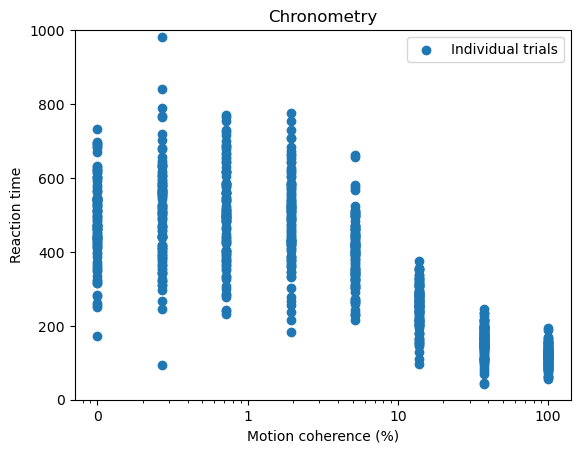

In [8]:
# Solution
def plot_reaction_time(data: pd.DataFrame, model=None):
    ## Add your code here (ignore the 'model' argument for now)
    plt.scatter(data['motion_coherence'], data['reaction_time'], label='Individual trials')

    plt.title("Chronometry")
    plt.ylabel("Reaction time")
    plt.xlabel("Motion coherence (%)")
    plt.xscale('log')
    plt.ylim(0, 1000)
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.legend()

    #########
    plt.show()


# Here we call the function on your dataset
plot_reaction_time(data)


### b) Accuracy
In this one, we won't plot each trial individually. Instead, we want to aggregate the outcomes of the trials corresponding to each motion coherence rate. In other words, your graph should display only 8 points, showing the accuracy of the participant for each coherence level.  
*Hint*: You can look at pandas' `groupby` method to perform data aggregation on a specific attribute.

In [9]:
# Fill the missing code
def plot_accuracy(data, model=None):
    ## Add your code here
    ...
    

    ########
    plt.show()

# We call the function on your dataset
plot_accuracy(data)

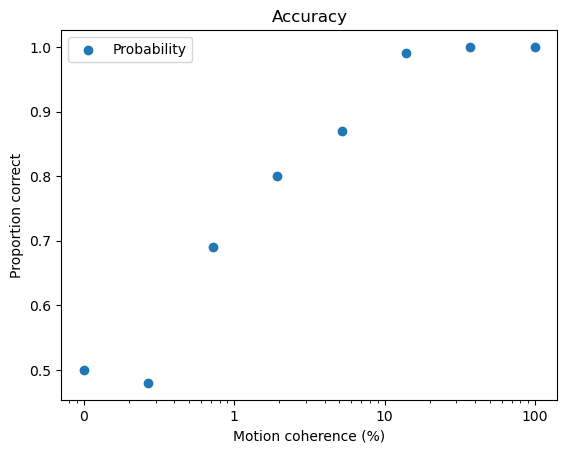

In [10]:
# Solution
def plot_accuracy(data, model=None):
    ## Add your code here
    accuracy = data.groupby('motion_coherence')['outcome'].mean()
    plt.scatter(accuracy.index, accuracy, label='Probability')
    
    plt.title("Accuracy")
    plt.ylabel("Proportion correct")
    plt.xlabel("Motion coherence (%)")
    plt.xscale('log')
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())
    plt.legend()

    ########
    plt.show()

# We call the function on your dataset
plot_accuracy(data)

## Model
We will now implement the two descriptive equations that come with the model. The structure of the class is given to you, but you should implement the methods. Here are the equations again.
</br>
<img src="images/equations.png" style="height: 300px; margin-left: 10px;" />

📝 Write all three methods of the class below (including the constructor, i.e. the `__init__()` method)

In [11]:
class MotionCoherenceModel:
    def __init__(self, A, k, t_R):
        pass ## Your code here

    def predict_mean_reaction_time(self, x: np.ndarray) -> np.ndarray:
        pass ## Your code here

    def predict_accuracy(self, x: np.ndarray) -> np.ndarray:
        pass ## Your code here


In [12]:
# Solution
class MotionCoherenceModel:
    def __init__(self, A, k, t_R):
        self.A = A
        self.k = k
        self.t_R = t_R

    def predict_mean_reaction_time(self, x: float | np.ndarray) -> float | np.ndarray:
        t_T = self.A / (self.k * x) * np.tanh(self.A * self.k * x) + self.t_R
        return t_T

    def predict_accuracy(self, x: float | np.ndarray) -> float | np.ndarray:
        p_c = 1 / (1 + np.exp(-2 * self.A * self.k * np.abs(x)))
        return p_c

### Try your model
Now you can instantiate your MotionCoherenceModel class with parameter values of your choice.
Don't worry if you don't know what parameter values to give. Just try to guess for now.

In [13]:
test_model = ...

In [14]:
# Solution
test_model = MotionCoherenceModel(A=50, k=0.1, t_R=200)

Now, let's visualize your model's predictions on top of the graphs you generated previously. Given a motion coherence level $x$, your model can predict:
- The average reaction time of a participant on trials with that motion coherence level
- The average accuracy on trials with that motion coherence level.

📝 **Edit your plotting functions** that you wrote in the Data Visualization section so that you can pass them your `test_model` as the last argument. You'll plot your model's predictions as a line on top of the scatter plot that contains the data points. For this, you can proceed in two ways, depending on your level coding proficiency.
- 💪 In the plotting function, you can simply call your model's predict_** method with the 8 different values of motion coherence that are used in the experiment's stimuli and make a line plot.
- 💪💪 You go a step further and generate a full range of about 1000 coherence motion values on a log scale between 0.01 and 100, and get your model's predictions on it. It will make a much smoother line to visualize your model's prediction.

📝 Use your updated `plot_reaction_time` function to see your model's average reaction time predictions along with the data points

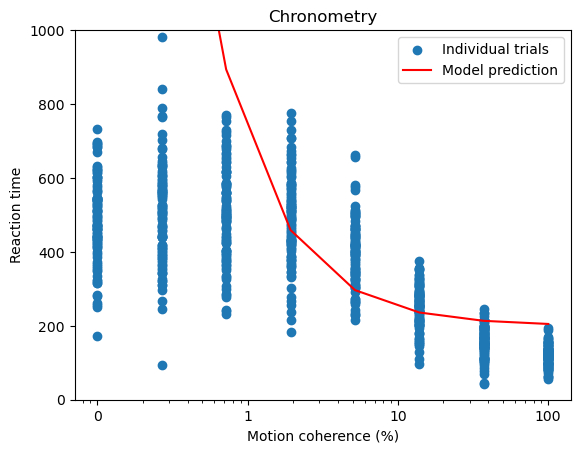

In [15]:
# Solution
def plot_reaction_time(data, model=None):
    plt.scatter(data['motion_coherence'], data['reaction_time'], label='Individual trials')

    ## Update
    pred = model.predict_mean_reaction_time(data['motion_coherence'])
    plt.plot(data['motion_coherence'], pred, label='Model prediction', c='red')
    #########

    plt.title("Chronometry")
    plt.ylabel("Reaction time")
    plt.xlabel("Motion coherence (%)")
    plt.xscale('log')
    plt.ylim(0, 1000)
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.legend()
    plt.show()


plot_reaction_time(data, model=test_model)

📝 Use your updated `plot_accuracy` function to see your model's average accuracy predictions along with the data averages

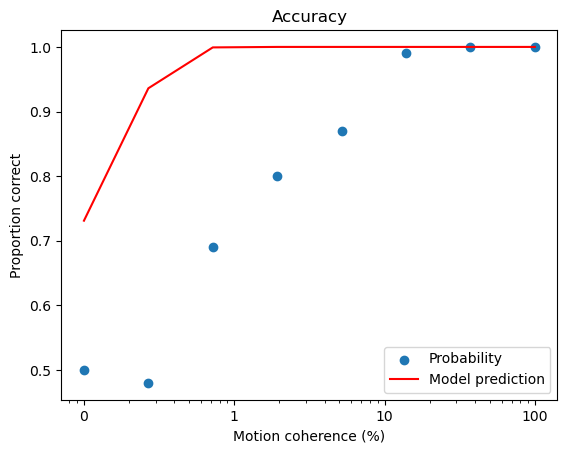

In [16]:
# Solution
def plot_accuracy(data, model=None):
    accuracy = data.groupby('motion_coherence')['outcome'].mean()
    plt.scatter(accuracy.index, accuracy, label='Probability')

    ## Update
    pred = model.predict_accuracy(data['motion_coherence'])
    plt.plot(data['motion_coherence'], pred, label='Model prediction', c='red')
    ########

    plt.title("Accuracy")
    plt.ylabel("Proportion correct")
    plt.xlabel("Motion coherence (%)")
    plt.xscale('log')
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())
    plt.legend()
    plt.show()

# We call the function on your dataset
plot_accuracy(data, model=test_model)

⚙ Now play around a bit with your model's parameters and try to find values that can fit the data visually (on both accuracy and reaction time).    
If you find the right parameters, you should obtain an 'S' shape on both graphs, like in the figure above.

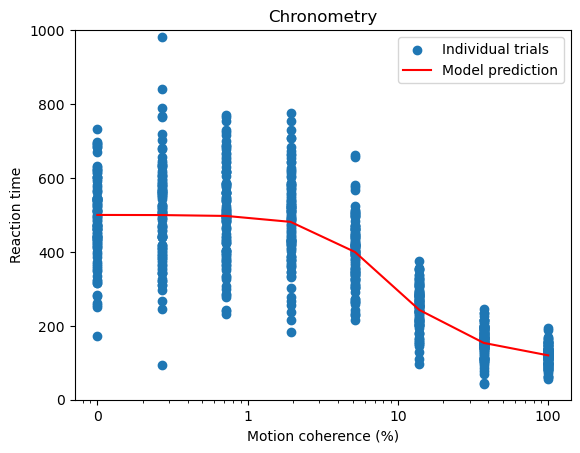

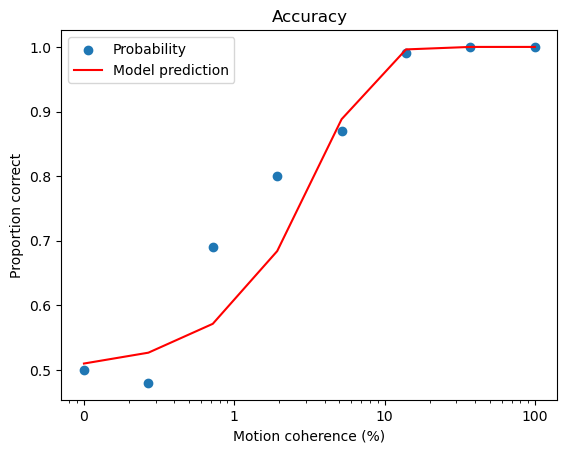

In [17]:
# Solution
better_model = MotionCoherenceModel(A=20, k=0.01, t_R=100)
plot_reaction_time(data, better_model)
plot_accuracy(data, model=better_model)

## Model fitting
Now that we understand how the model parameters influence the model's predictions, we will now see how we can find the appropriate parameter values automatically through optimization.

Last time, the fitting code was all provided for you, but today we will start to dig into how it's done. For that, we need to know a bit more about parameter optimization. Standart optimization methods start by defining a **cost function** that we attempt to **minimize**. This cost function must take model's outputs and evaluate how far they are from the actual values found in the data.

Once we have defined the cost function, we can ask a standard optimization software to **minimize** it to get the parameter values that produce the model that best fits the behavior data.

### Define a cost function
We will start by defining a cost function on the accuracy predictions (so we ignore the chronometry for now).
For this, we need to compare:
- `predictions`: for any motion coherence value, the model can give the expected accuracy of the participants
- `targets`: we have data, so we can compute the accuracy of the subject on each motion coherence level. Actually, you have already computed the accuracy associated with each of the 8 levels of motion coherence when you made the s-shaped scatter plot. You will reuse the same code here.

📝 Fill the code below:
- The variables `prediction` and `targets` should hold an array of 8 values each.
- The `cost` must be a measure of how far the predictions are from the targets. I let you think about it a little bit before pointing you the usual metric that is used. How would you define the magnitude of your model's error *on each data point indiviudally*?

In [18]:
def accuracy_cost_function(parameters, data=data):
    A, k, t_R = parameters

    # Instantiate a model with the tested parameter values
    candidate_model = ...

    # Generate accuracy predictions with a model that has the given parameter values
    predictions = ...

    # Extract the target values from the dataset
    targets = ...

    # Compute how far the predictions are from the targets
    cost = ...

    return cost

In [38]:
# Solution
def accuracy_cost_function(parameters, data=data):
    A, k, t_R = parameters

    # Instantiate a model with the tested parameter values
    candidate_model = MotionCoherenceModel(A, k, t_R)

    # Generate predictions with a model that has the given parameter values
    predictions = candidate_model.predict_accuracy(data['motion_coherence'].unique())

    # Extract the target values from the dataset
    targets = data.groupby('motion_coherence')['outcome'].mean().values

    # Compute how far the predictions are from the targets
    cost = ((targets - predictions) ** 2).mean()

    return cost

#### Test your cost function
Here are a few unit tests that you can run to check if your function works correctly

In [58]:
result = accuracy_cost_function((10, 1, 10))
assert isinstance(result, float), "Your cost function should return a real number (a float)"
assert np.isclose(result, 0.07046096), "Your computation of the cost is not correct"
print("OK 👌")

OK 👌


### Fit your model!
📝 Call the `minimize` function with the cost function you defined. There are extra steps hidden underneath this function because we have to define prior distributions for the parameters, but for today we will not worry about it and leave it for a future session!  
💪💪 If you are ahead your classmates, you are more than welcome to implement the `minimize` function yourself without looking at the one that I wrote in `utils.py`. It uses the `pybads` package, but you can also use your favorite optimization library if you prefer.

In [21]:
params_optimized_for_accuracy = ...

In [22]:
# Solution
params_optimized_for_accuracy = minimize(accuracy_cost_function)

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2       0.0613813               1                                 Uncertainty test
     0           6       0.0500683               1         Initial mesh            Initial points
     0          11       0.0500683             0.5         Refine grid             Train
     1          13       0.0499548             0.5     Incremental search (ES-wcm)        
     1          21       0.0499548            0.25         Refine grid             Train
     2          22       0.0498538            0.25     Incremental search (ES-ell)        
     2          24       0.0498228            0.25     Incremental search (ES-wcm)        
     2          31       0.0498228           0.125         Refine grid             Train
     3          32       0.0498169      

### Visualize your optimized model's predictions

📝 Instantiate a new model with the parameters that were optimized for accuracy

In [23]:
model_optimized_for_accuracy = ...

In [24]:
# Solution
model_optimized_for_accuracy = MotionCoherenceModel(**params_optimized_for_accuracy)

📝 Plot the the accuracy predictions of your model against the data using your `plot_accuracy` function

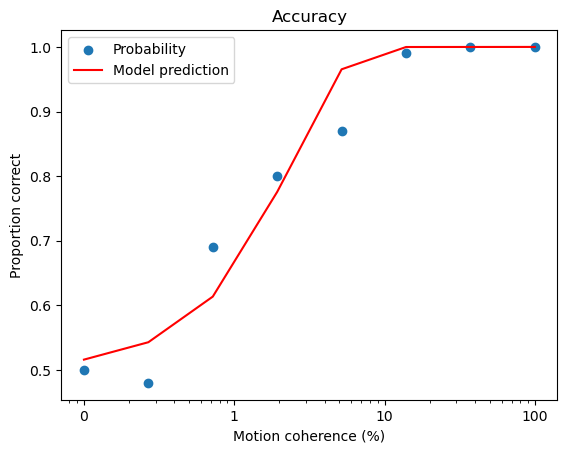

In [25]:
# Solution
plot_accuracy(data, model_optimized_for_accuracy)

📝 Now plot the reaction time predictions of your models against the data using your `plot_reaction_time` function.

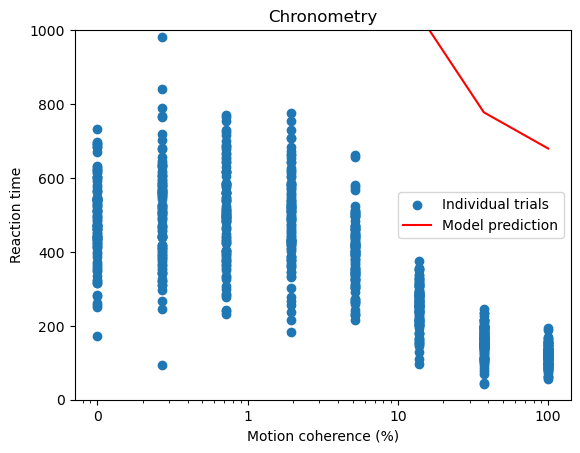

In [26]:
# Solution
plot_reaction_time(data, model_optimized_for_accuracy)

🤔 You might notice that your model can predict the accuracy very well, but not the chronometry (reaction time). Why do you think this is the case?  
Look again at the equations that we implemented for chronometry and accuracy and see if you can come up with an explanation. Find the answer to this question before you move on. You can obviously ask me!


## Write a different cost function
📝 Now, let's write a cost function that evaluates the error in the prediction of average response time.

In [27]:
def rt_cost_function(parameters):
    A, k, t_R = parameters

    # Instantiate a model with the tested parameter values
    candidate_model = ...

    # Generate average response time predictions with a model that has the given parameter values
    predictions = ...

    # Extract the target values from the dataset
    targets = ...

    # Compute how far the predictions are from the targets
    cost = ...

    return cost

In [28]:
# Solution
def rt_cost_function(parameters):
    A, k, t_R = parameters

    # Instantiate a model with the tested parameter values
    candidate_model = MotionCoherenceModel(A, k, t_R)

    # Generate average response time predictions with a model that has the given parameter values
    predictions = candidate_model.predict_mean_reaction_time(data['motion_coherence'].unique())

    # Extract the target values from the dataset
    targets = data.groupby('motion_coherence')['reaction_time'].mean().values

    # Compute how far the predictions are from the targets
    cost = np.sqrt(((predictions - targets) ** 2).mean())

    return cost

📝 Run the optimization with this new cost function

In [29]:
#Solution
params_optimized_for_rt = minimize(rt_cost_function)

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         7.02283               1                                 Uncertainty test
     0           6         7.02283               1         Initial mesh            Initial points
     0          10         7.02283             0.5         Refine grid             Train
     1          19         7.02283            0.25         Refine grid             Train
     2          29         7.02283           0.125         Refine grid             Train
     3          39         7.02283          0.0625         Refine grid             Train
     4          42         6.46907          0.0625     Successful search (ES-wcm)        
     4          46         6.33899          0.0625     Successful search (ES-wcm)        
     4          48         6.33602          

### Visualize the predictions of a model optimized for the prediction of the average response time

📝 Instantiate a new model with the parameters that were optimized for response time

In [30]:
model_optimized_for_rt = ...

In [31]:
# Solution
model_optimized_for_rt = MotionCoherenceModel(**params_optimized_for_rt)

📝 Plot the reaction time predictions of your models against the data using your `plot_reaction_time` function.

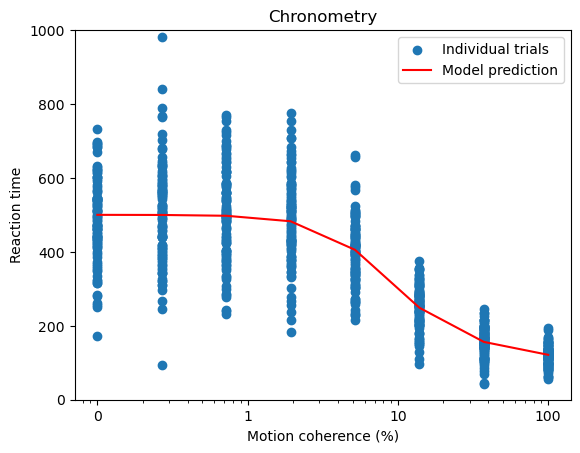

In [32]:
# Solution
plot_reaction_time(data, model_optimized_for_rt)

📝 Now plot the the accuracy predictions of your model against the data using your `plot_accuracy` function

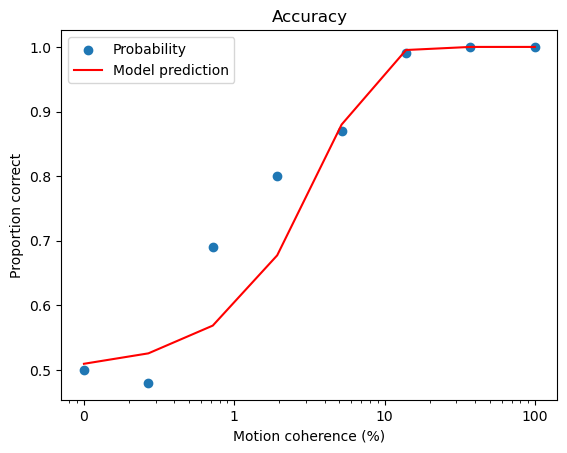

In [33]:
# Solution
plot_accuracy(data, model_optimized_for_rt)

### Combined cost function
It could be possible to run the optimization on a cost function that combines accuracy and reaction time data. Do you have an idea of how you could do this? Try something out and see what result you get.  
Do you see an advantage for using both accuracy and reaction times in your cost function, even though the fit on reaction time alone was already sufficient to learn all parameters?

In [34]:
def combined_cost_function(parameters):
    cost = ...
    
    return cost

# Optional exercise: generative model
💪💪 If you are finished and want more to dig futher, you can implement the **generative model** that goes with the Drift-Diffusion model. This means that you can implement the actual drift process that is shown in the figure below. This part of the TD is more free, and there will not be a proper solution given for it. Feel free to share yours!

<img src="images/drift_diffusion_model.png" style="height: 300px; margin-left: 10px;" />

You should look at the original paper (open access) to understand how the model works. The detailed equations are provided in the appendix.
>Palmer, J., Huk, A. C., & Shadlen, M. N. (2005). The effect of stimulus strength on the speed and accuracy of a perceptual decision. Journal of Vision, 5(5), 376–404. https://doi.org/10.1167/5.5.1

### Write the model
📝 Extend the `MotionCoherenceModel` class with a `simulate` method. This method should:
- take as an input a motion coherence
- perform the drift diffusion process using the A, k and t_R parameters (you might want to look online to see how this plays out)
- return the response and the reaction time  
_**Note:**_ You should write **vectorized** operations, what is, *x* should be an array containing many trials, and your `simulate` method should simulate them all in parallel and return an array of responses and reaction times.

In [35]:
class GenerativeMotionCoherenceModel(MotionCoherenceModel):
    def simulate(x):
        # Write this function
        ...
        
        response = ...
        reaction_time = ...
        return response, reaction_time

### Simulate data

📝 Using your `GenerativeMotionCoherenceModel` instantiated with the optimal parameter values that you found, simulate a dataset of the same size as the one in `data.csv`. Use the same motion coherence levels and the same number of trials

### Visualize your dataset
Use your two plotting functions to see if your simulated data looks like the dataset.

### Recover parameters
Fit a MotionCoherenceModel to your simulated data and see if you find back the same parameters.